In [1]:
%%latex
InteractiveShell.ast_node_interactivity = "all"

<IPython.core.display.Latex object>

In [2]:
from scipy.special import gamma
from scipy.integrate import quad
from cmath import sqrt as csqrt
# import spherical harmonics
from scipy.special import sph_harm
# multiple line output
from IPython.core.interactiveshell import InteractiveShell
import numpy as np
from functools import lru_cache
from collections import defaultdict
from decimal import Decimal
from functools import lru_cache
from sympy import S
from sympy.physics.wigner import wigner_3j

In [3]:
rp  = 1.0
q   = 2.0/100. # qr_+
h0  = 0.5 + csqrt(0.25 - q**2) # h w/ L=0
iq  = 1j*q
Q   = 1.0

In [4]:
# def complex conjugate of a function
def bar(f):
    """
    Calculate the complex conjugate of a function.
    """
    return np.conj(f)

def h(l):
    d2 = 0.25 + l*(l+1) - q**2
    if d2 > 0:
        return 0.5 + csqrt(d2)
    else:
        return 0.5 - csqrt(d2)

# QNM frequencies

In [5]:
def s(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return - (n + h(l) + iq) / 2.


def w(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return -1j * (n + h(l) + iq) / 2.

In [6]:
def poch(a,n):
    """
    Pochhammer symbol
    """
    if type(n) == int:
        return (-1)**n * gamma(1-a)/gamma(1-a-n)
    else:
        return gamma(a+n)/gamma(a)

# Q coefficients

In [7]:
@lru_cache(None)
def W3j(j1, j2, j3, m1, m2, m3):
    """
    Cached Wigner 3j symbol.

    Uses SymPy's exact implementation internally, then converts to float.
    """

    # Selection rule
    if m1 + m2 + m3 != 0:
        return 0.0

    # Magnetic bounds
    if abs(m1) > j1 or abs(m2) > j2 or abs(m3) > j3:
        return 0.0

    # Triangle inequality
    if j3 < abs(j1 - j2) or j3 > j1 + j2:
        return 0.0

    return float(wigner_3j(
        S(j1), S(j2), S(j3),
        S(m1), S(m2), S(m3)
    ))

In [8]:
W3j(0,0,0,0,0,0)==1

True

In [9]:
# symmetric angular coupling coefficient Q^{ij}_{kp} = ∫ Y_i Y_j bar(Y_k) bar(Y_p)
#
def Q_element(li, mi, lj, mj, lk, mk, lp, mp):
    """
    Compute

        Q^{ij}_{kp} = ∫_{S^2} dΩ Y_i Y_j \bar{Y}_k \bar{Y}_p

    using the Wigner-3j formula

        Q^{ij}_{kp}
        =
        sum_l (-1)^{m + mk + mp}
        (2l+1)/(4π)
        sqrt[(2li+1)(2lj+1)(2lk+1)(2lp+1)]
        *
        (li lj l; 0 0 0)
        (li lj l; mi mj -m)
        (lk lp l; 0 0 0)
        (lk lp l; -mk -mp m)

    where m = mi + mj = mk + mp.
    """

    # Magnetic selection rule
    if mi + mj != mk + mp:
        return 0.0

    m = mi + mj

    # Triangle bounds from both pairs, plus |m| <= l.
    ell_min = max(abs(li - lj), abs(lk - lp), abs(m))
    ell_max = min(li + lj, lk + lp)

    if ell_min > ell_max:
        return 0.0

    pref = np.sqrt(
        (2*li + 1) *
        (2*lj + 1) *
        (2*lk + 1) *
        (2*lp + 1)
    ) / (4*np.pi)

    phase = (-1)**(m + mk + mp)

    total = 0.0

    for ell in range(ell_min, ell_max + 1):

        # Optional parity shortcuts:
        # (l1 l2 ell; 0 0 0) vanishes unless l1+l2+ell is even.
        if (li + lj + ell) % 2 != 0:
            continue
        if (lk + lp + ell) % 2 != 0:
            continue

        term = (
            phase
            * (2*ell + 1)
            * pref
            * W3j(li, lj, ell, 0, 0, 0)
            * W3j(li, lj, ell, mi, mj, -m)
            * W3j(lk, lp, ell, 0, 0, 0)
            * W3j(lk, lp, ell, -mk, -mp, m)
        )

        total += term

    return total


In [10]:
Q_element(0, 0, 0, 0, 0, 0, 0, 0)

0.07957747154594767

# near-zone radial coefficients

In [11]:
# normalization factor for the near-zone radial functions s.t <R_nl, R_nl> = 1
def Anorm(n, l):
    tmp = (  1j * (-1.)**(h(l)+iq) * 2. * gamma(n+1.) * gamma(2*h(l)+n) * gamma(1-h(l)-n-iq)  ) / ( gamma(h(l)-iq) * poch(h(l)+iq,n) )
    return csqrt(tmp)

In [12]:
Anorm(2,10)

(4598.718144782148-18.35628533183092j)

In [13]:
def P(j,n,ell):
    return poch(-n, j) * poch(1-2*h(ell)-n, j) / ( gamma(j+1)*poch(1-h(ell)-n-iq,j) )

def PLM(j, k1):
    return poch(-k1['n'], j) * poch(1-2*h(k1['l'])-k1['n'], j) / ( gamma(j+1)*poch(1-h(k1['l'])-k1['n']-iq,j) )

def P2(k,n,m,ell):
    tmp = 0
    for j in range(0, k+1):
        tmp += P(k-j,n,ell)*P(j,m,ell)
    return tmp

def P3(i,n,m,p,ell):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2(j,p,m,ell)*bar(P(i-j,n,ell))
    return tmp

def P4(i,n,m,p,q,ell):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3(j,q,p,m,ell)*P(i-j,n,ell)
    return tmp

def P2LMn(k, k1, k2):
    tmp = 0
    for j in range(0, k+1):
        tmp += PLM(k-j,k1)*PLM(j,k2)
    return tmp

def P3LMn(i, k1, k2, k3):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2LM(j,k3,k2)*bar(PLM(i-j,k1))
    return tmp

def P4LMn(i, k1, k2, k3, K):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3LM(j,K,k3,k2)*PLM(i-j,k1)
    return tmp

def P2LM(k, k1, k2):
    tmp = 0
    for j in range(0, k+1):
        tmp += PLM(k-j,k1)*PLM(j,k2)
    return tmp

def P3LM(i, k1, k2, k3):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2LM(j,k1,k2)*bar(PLM(i-j,k3))
    return tmp

def P4LM(i, k1, k2, k3, K):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3LM(j,k1,k2,k3)*PLM(i-j,K)
    return tmp


In [14]:
P4LMn(10,({ 'n': 10, 'l': 1}), ({ 'n': 30, 'l': 1}), ({ 'n': 20, 'l': 1}), ({ 'n': 1, 'l': 1}))

(268669768990.13318-1636243009.5837204j)

In [15]:
P4(10,10,30,20,1,1)

(268667724444.19-2001697937.4323893j)

In [16]:
@lru_cache(None)
def PLM_cached(j, n, ell):
    return (
        poch(-n, j)
        * poch(1 - 2*h(ell) - n, j)
        / (gamma(j + 1) * poch(1 - h(ell) - n - iq, j))
    )


def PLM(j, mode):
    return PLM_cached(j, mode["n"], mode["l"])

In [17]:
def C_abcd(i, a, b, c, d):
    """
    Coefficient C_i^{(a,b,c,d)} with the barred slot b
    """

    total = 0

    for j in range(i + 1):
        for k in range(j + 1):
            for ell in range(k + 1):
                total += (
                    PLM(i - j, a)
                    * bar(PLM(j - k, b))
                    * PLM(k - ell, c)
                    * PLM(ell, d)
                )

    return total

def P4LMn_as_C_abcd(i, a, b, c, d):
    return P4LMn(i, a, b, d, c)

In [18]:
A = {'n': 10, 'l': 1}
B = {'n': 30, 'l': 1}
C = {'n': 20, 'l': 1}
D = {'n': 1,  'l': 1}

x = C_abcd(10, A, B, C, D)
y = P4LMn_as_C_abcd(10, A, B, C, D)

print(x)
print(y)
print(x - y)

(268669768990.13312-1636243009.5837204j)
(268669768990.13318-1636243009.5837204j)
(-6.103515625e-05+0j)


In [19]:

# to match the paper ordering of slots, we define gamma_abcd and Scomp_abcd with the barred slot b in the second position.

def gamma_abcd(a, b, c, d):
    """
    gamma_abcd = s_a + bar(s_b) + s_c + s_d.
    """

    return (
        s(a["n"], a["l"])
        + bar(s(b["n"], b["l"]))
        + s(c["n"], c["l"])
        + s(d["n"], d["l"])
    )


def Scomp_abcd(j, a, b, c, d):
    """
    Finite-part coefficient (check S_abcd)_j.

    This is your old ScompLM, but with explicit slot order.
    """

    gam = gamma_abcd(a, b, c, d)

    return (
        (-1)**(j + gam + 1)
        * gamma(1 + j + gam)
        * gamma(-1 - j - 2*gam - 2*iq)
        / gamma(-2*iq - gam)
    )

def S_near_abcd(a, b, c, d):
    """
    Compute the near-zone coefficient with slots

        a, bar(b), c, d.

    This corresponds to the paper's C_i^{(a,b,c,d)} convention.
    """

    Ntot = a["n"] + b["n"] + c["n"] + d["n"]

    # Your convention appears to use 1/Anorm as the actual N-factor.
    norm = (
        1 / Anorm(a["n"], a["l"])
        / bar(Anorm(b["n"], b["l"]))
        / Anorm(c["n"], c["l"])
        / Anorm(d["n"], d["l"])
    )

    total = 0

    for j in range(Ntot + 1):
        total += C_abcd(j, a, b, c, d) * Scomp_abcd(j, a, b, c, d)

    return norm * total

In [20]:
# call S_near_abcd with the same arguments as SLM to check consistency
S_near_abcd({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0})

(1.4584782671720797e-07-6.1686362363695345e-06j)

In [21]:
def Scomp(j, ntot):
   c = -0.5*(4.*h0  + 2.*iq + ntot)
   return ( (-1)**(j+c+1) * gamma(1 + j + c)*gamma(-1 - j - 2*c - 2*iq) ) / gamma(-2*iq - c)
def ScompLM(j, k1, k2 ,k3, K):
    c  = s(k1['n'],k1['l']) + s(k2['n'],k2['l']) + s(k3['n'],k3['l'])  + bar(s(K['n'],K['l']))
    #c = -0.5*(h(k1['l']) + h(k2['l']) + h(k3['l']) + h(K['l']) + 2*iq + k1['n'] + k2['n'] + k3['n'] + K['n'])
    return ( (-1)**(j+c+1) * gamma(1+j+c)*gamma(-1-j-2.*c-2.*iq) ) / gamma(-2.*iq-c)

In [22]:
def SLM(k1, k2, k3, K):
    ntot = k1['n'] + k2['n'] + k3['n'] + K['n']
    norms = 1/Anorm(k1['n'],k1['l'])/Anorm(k2['n'],k2['l'])/Anorm(k3['n'],k3['l'])/bar(Anorm(K['n'],K['l']))
    Slm = P4LMn(0, k1, K, k2, k3)*ScompLM(0, k1, k2, k3, K)
    for i in range(1, ntot+1):
        Slm +=  P4LM(i, k1, k2, k3, K)*ScompLM(i, k1, k2, k3, K)
        #Slm +=  P4LMn(i, k1, K, k2, k3)*ScompLM(i, k1, k2, k3, K)
    return norms*Slm

def S0(n1,n2,n3,N):
    ntot= n1+n2+n3+N
    ell = 0
    norms = 1/Anorm(n1,ell)/Anorm(n2,ell)/Anorm(n3,ell)/bar(Anorm(N,ell))
    S = P4(0, n1, n2, n3,N, ell)*Scomp(0, ntot)
    for i in range(1, ntot+1):
        S += P4(i, n1, n2, n3, N, ell)*Scomp(i, ntot)
    return norms*S

In [23]:
SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0}),\
    SLM({ 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}), \
    SLM({ 'n': 11, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 7, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}),SLM({ 'n': 7, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 2, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0})


((-1.9467700474519627e-07+2.2220617734646725e-06j),
 (-3.5187314702527105e-08+8.043689177743946e-07j),
 (-1.9467701099673152e-07+2.222061807976802e-06j),
 (-3.518285948003132e-08+8.043696498500855e-07j),
 (6.432638541118607e-07-6.136738961708588e-06j),
 (6.432627337035988e-07-6.136739099173927e-06j),
 (-1.9467700474519627e-07+2.2220617734646725e-06j))

In [24]:
S0(11,20,2,1)

(0.00028520586668244913+0.00017263454857656917j)

In [25]:
SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 1, 'l': 0})
SLM({ 'n': 2, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0})
SLM({ 'n': 20, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0})
S_near_abcd({ 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 11, 'l': 0})

(0.0002911868343018056+0.00012927379252952975j)

In [26]:
import itertools

def create_SLM_table(K):
    # Prepare the ranges for n and l
    n_range = range(3)  # n = 0 ...
    l_range = range(5)  # l = 0 ...

    # Table to store results in the form (n1, l1, n2, l2, n3, l3, SLM_value)
    table = []

    # Loop through all combinations of n and l for k1, k2, and k3
    for k1_n, k2_n, k3_n in itertools.product(n_range, repeat=3):
        for k1_l, k2_l, k3_l in itertools.product(l_range, repeat=3):

            # Define the dictionary objects for k1, k2, k3
            k1 = {'n': k1_n, 'l': k1_l, 'm': 0}  # m is assumed to be 0 in your example
            k2 = {'n': k2_n, 'l': k2_l, 'm': 0}
            k3 = {'n': k3_n, 'l': k3_l, 'm': 0}

            # Canonical ordering of k1, k2, k3 (k1 <= k2 <= k3)
            k_list = sorted([k1, k2, k3], key=lambda x: (x['n'], x['l']))
            k1_canonical, k2_canonical, k3_canonical = k_list

            # Compute SLM for the canonical ordering
            Slm_value = SLM(k1_canonical, k2_canonical, k3_canonical, K)

            # Add the result to the table
            table.append({
                'n1': k1_canonical['n'], 'l1': k1_canonical['l'],
                'n2': k2_canonical['n'], 'l2': k2_canonical['l'],
                'n3': k3_canonical['n'], 'l3': k3_canonical['l'],
                'n4b': K['n'], 'l4b': K['l'],
                'SLM_value': Slm_value
            })

    # The table is a list of dictionaries, you can convert it into a pandas DataFrame for easier manipulation if desired
    return table




In [27]:
# Example usage
K = {'n': 5, 'l': 1, 'm': 0}  # Example value for K
slm_table = create_SLM_table(K)

# Optionally, convert to a pandas DataFrame if desired
import pandas as pd
df = pd.DataFrame(slm_table)
print(df)

      n1  l1  n2  l2  n3  l3  n4b  l4b  \
0      0   0   0   0   0   0    5    1   
1      0   0   0   0   0   1    5    1   
2      0   0   0   0   0   2    5    1   
3      0   0   0   0   0   3    5    1   
4      0   0   0   0   0   4    5    1   
...   ..  ..  ..  ..  ..  ..  ...  ...   
3370   2   0   2   4   2   4    5    1   
3371   2   1   2   4   2   4    5    1   
3372   2   2   2   4   2   4    5    1   
3373   2   3   2   4   2   4    5    1   
3374   2   4   2   4   2   4    5    1   

                                           SLM_value  
0     3.486936e-10+5.718845e-                    09j  
1    -2.047345e-09-5.823532e-                    08j  
2    -3.144923e-11-5.073354e-                    10j  
3     7.228787e-10+1.938094e-                    08j  
4     2.348858e-11+3.782214e-                    10j  
...                                              ...  
3370 -4.313023e-07-8.890773e-                    06j  
3371 -1.024602e-08-2.531631e-                    07j  


In [28]:
df

,n1,l1,n2,l2,n3,l3,n4b,l4b,SLM_value
0,0,0,0,0,0,0,5,1,3.486936e-10+5.718845e- 09j
1,0,0,0,0,0,1,5,1,-2.047345e-09-5.823532e- 08j
2,0,0,0,0,0,2,5,1,-3.144923e-11-5.073354e- 10j
3,0,0,0,0,0,3,5,1,7.228787e-10+1.938094e- 08j
4,0,0,0,0,0,4,5,1,2.348858e-11+3.782214e- 10j
...,...,...,...,...,...,...,...,...,...
3370,2,0,2,4,2,4,5,1,-4.313023e-07-8.890773e- 06j
3371,2,1,2,4,2,4,5,1,-1.024602e-08-2.531631e- 07j
3372,2,2,2,4,2,4,5,1,-1.414547e-07-2.856686e- 06j
3373,2,3,2,4,2,4,5,1,-7.379253e-09-1.731890e- 07j


In [29]:
def create_SLM_table_optimized(K):
    # Prepare the ranges for n and l
    n_range = range(1)  # n = 0 to 2
    l_range = range(5)  # l = 0 to 4 (can be adjusted)

    # Dictionary to store previously computed SLM_values
    computed_slm_values = {}

    # Table to store results in the form (n1, l1, n2, l2, n3, l3, SLM_value)
    table = []

    # Loop through all combinations of n and l for k1, k2, and k3
    for k1_n, k2_n, k3_n in itertools.product(n_range, repeat=3):
        for k1_l, k2_l, k3_l in itertools.product(l_range, repeat=3):

            # Define the dictionary objects for k1, k2, k3
            k1 = {'n': k1_n, 'l': k1_l, 'm': 0}  # m is assumed to be 0 in your example
            k2 = {'n': k2_n, 'l': k2_l, 'm': 0}
            k3 = {'n': k3_n, 'l': k3_l, 'm': 0}

            # Canonical ordering of k1, k2, k3 (k1 <= k2 <= k3)
            k_list = sorted([k1, k2, k3], key=lambda x: (x['n'], x['l']))
            k1_canonical, k2_canonical, k3_canonical = k_list

            # Generate a unique key for this triplet (to use in the cache)
            triplet_key = (k1_canonical['n'], k1_canonical['l'],
                           k2_canonical['n'], k2_canonical['l'],
                           k3_canonical['n'], k3_canonical['l'])

            # Check if the result for this triplet has already been computed
            if triplet_key not in computed_slm_values:
                # Compute SLM for the canonical ordering
                Slm_value = SLM(k1_canonical, k2_canonical, k3_canonical, K)
                # Store the computed value in the cache
                computed_slm_values[triplet_key] = Slm_value
            else:
                # Retrieve the previously computed value
                Slm_value = computed_slm_values[triplet_key]

            # Add the result to the table
            table.append({
                'n1': k1_canonical['n'], 'l1': k1_canonical['l'],
                'n2': k2_canonical['n'], 'l2': k2_canonical['l'],
                'n3': k3_canonical['n'], 'l3': k3_canonical['l'],
                'SLM_value': Slm_value
            })

    # The table is a list of dictionaries, you can convert it into a pandas DataFrame for easier manipulation if desired
    return table

In [30]:
# Example usage
K = {'n': 2, 'l': 1, 'm': 0}  # Example value for K
slm_table = create_SLM_table_optimized(K)

# Optionally, convert to a pandas DataFrame if desired
df = pd.DataFrame(slm_table)
df


,n1,l1,n2,l2,n3,l3,SLM_value
0,0,0,0,0,0,0,-1.986256e-07-6.654609e- 05j
1,0,0,0,0,0,1,-1.888145e-08-5.090672e- 07j
2,0,0,0,0,0,2,3.317567e-07+2.770926e- 05j
3,0,0,0,0,0,3,2.456731e-05+6.580903e- 04j
4,0,0,0,0,0,4,6.276971e-07+4.839158e- 05j
...,...,...,...,...,...,...,...
120,0,0,0,4,0,4,9.244321e-07+4.026234e- 05j
121,0,1,0,4,0,4,2.096443e-05+5.330120e- 04j
122,0,2,0,4,0,4,9.661921e-07+3.023651e- 05j
123,0,3,0,4,0,4,1.773944e-05+4.482845e- 04j


In [31]:
slm_table

[{'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 0,
  'SLM_value': (-1.9862555716636408e-07-6.65460930697224e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 1,
  'SLM_value': (-1.8881450351826662e-08-5.090671998647843e-07j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 2,
  'SLM_value': (3.31756736808713e-07+2.770926291423897e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 3,
  'SLM_value': (2.4567308996717414e-05+0.0006580902617281836j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 4,
  'SLM_value': (6.276970814529578e-07+4.8391578642428404e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 1,
  'SLM_value': (-1.8881450351826662e-08-5.090671998647843e-07j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 1,
  'n3': 0,
  'l3': 1,
  'SLM_value': (4.5448766073191955e-07+2.529623091513555e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 1,
  'n3': 0,
  'l3': 2,
  'SLM_value': (2

# dynamical system

In [32]:
from scipy.integrate import solve_ivp

Configure evolution parameters

In [33]:
eps = 0.02
T = 500.0  #evolution time

In [34]:
modes_mixed = [
    {"n": 1, "l": 1, "m": 1},
    {"n": 2, "l": 1, "m": -1},
    {"n": 7, "l": 1, "m": 1},
    {"n": 11, "l": 1, "m": 0},
]

modes = [
    {"n": 1, "l": 0, "m": 0},
    {"n": 2, "l": 0, "m": 0},
    {"n": 7, "l": 0, "m": 0},
    {"n": 11, "l": 0, "m": 0},
]

modes_12 = [
    {"n": 1, "l": 1, "m": -1},
    {"n": 1, "l": 1, "m":  0},
    {"n": 1, "l": 1, "m":  1},
    {"n": 2, "l": 1, "m": -1},
    {"n": 2, "l": 1, "m":  0},
    {"n": 2, "l": 1, "m":  1},
]

In [35]:
# initial data

def make_A0_from_powers(powers, phases=None):
    powers = np.asarray(powers, dtype=float)
    powers = powers / np.sum(powers)

    if phases is None:
        phases = np.zeros_like(powers)

    return np.sqrt(powers) * np.exp(1j * np.asarray(phases))

# A0 = make_A0_from_powers( [0.40, 0.30, 0.20, 0.10, 0.13, 0.33], phases=[0.0, 0.7, 1.8, -0.4, 0.1, -0.34], )


A0 = np.array([1.0, 0.2*np.exp(0.3j), 0.1*np.exp(1.1j), 0.05*np.exp(-0.7j)], dtype=complex)


# Optional: normalize total action to 1
A0 = A0 / np.sqrt(np.sum(np.abs(A0)**2))

In [36]:
def omega_mode(J):
    # J is a dictionary with keys "n", "l" , and "m"
    return w(J["n"], J["l"])


omega_arr = np.array([omega_mode(J) for J in modes], dtype=complex)

In [37]:
def coupling_entry(lam, i, j, k, alpha=1.0):
    """
    C[lam,i,j,k] = c^{ij}_{lam,k}
                 = alpha Q^{ij}_{lam k} S^{ij lam}_k.
    """

    ki = modes[i]
    kj = modes[j]
    kk = modes[k]
    klam = modes[lam]

    Qi = Q_element(
        ki["l"], ki.get("m", 0),
        kj["l"], kj.get("m", 0),
        klam["l"], klam.get("m", 0),
        kk["l"], kk.get("m", 0),
    )

    # barred slot is kk
    Si = S_near_abcd(ki, kk, kj, klam)

    return alpha * Qi * Si


def build_coupling_tensor(modes, alpha=1.0):
    N = len(modes)
    C = np.zeros((N, N, N, N), dtype=complex)

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    C[lam, i, j, k] = coupling_entry(lam, i, j, k, alpha=alpha)

    return C

In [38]:
C = build_coupling_tensor(modes, alpha=1.0)

build the system $$ia_\lambda = \omega_\lambda a_\lambda + \sum_{123} c^{12}_{\lambda,3} a_1 a_2 \bar{a}_3$$

note that in sec 8.1 of my notes we chose the convention with the barred slot last position for the coupling, but here we are using the convention with the barred slot in the second position, so we have to write a wrapper to match the paper's convention for the coupling coefficients.

In [39]:
def S_notes(i, j, k, lam):
    """
    Notes convention:

        S^{ij lam}_k ~ b_i b_j bar(b_k) b_lam

    S_near_abcd(a,b,c,d) has b barred, so

        S_notes(i,j,k,lam) = S_near_abcd(i,k,j,lam).
    """
    return S_near_abcd(modes[i], modes[k], modes[j], modes[lam])

def Q_notes(i, j, k, lam):
    """
    Q^{ij}_{k lam} = ∫ Y_i Y_j bar(Y_k) bar(Y_lam).
    """

    mi = modes[i]
    mj = modes[j]
    mk = modes[k]
    ml = modes[lam]

    return Q_element(
        mi["l"], mi.get("m", 0),
        mj["l"], mj.get("m", 0),
        mk["l"], mk.get("m", 0),
        ml["l"], ml.get("m", 0),
    )
def build_C_notes(modes, alpha=1.0):
    """
    Build C[lam,i,j,k] = c^{ij}_{lam,k}

    so that

        i A_lam' = sum_{i,j,k}
                   C[lam,i,j,k] A_i A_j bar(A_k)
                   exp(i Omega[lam,i,j,k] t).
    """

    N = len(modes)
    C = np.zeros((N, N, N, N), dtype=complex)

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    C[lam, i, j, k] = (
                        alpha
                        * Q_notes(i, j, k, lam)
                        * S_notes(i, j, k, lam)
                    )

    return C

def build_Omega_notes(omega_arr, real_phase=False):
    """
    Omega[lam,i,j,k] = omega_lam + omega_k - omega_i - omega_j.
    """

    if real_phase:
        omega_arr = np.real(omega_arr)

    return (
        omega_arr[:, None, None, None]
        - omega_arr[None, :, None, None]
        - omega_arr[None, None, :, None]
        + omega_arr[None, None, None, :]
    )

def rhs_A_notes(t, A, eps, C, Omega, mask=None, phase_mode="exact"):
    """
    Notes convention:

        i A_lam' =
            eps^2 sum_{i,j,k}
            C[lam,i,j,k] A_i A_j bar(A_k)
            exp(i Omega[lam,i,j,k] t).
    """

    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    Ceff = C * mask * phase

    nonlinear = np.einsum(
        "lijk,i,j,k->l",
        Ceff,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * eps**2 * nonlinear

def build_nondiag_mask_notes(N):
    """
    Remove diagonal frequency-shift terms:

        A_q A_lam bar(A_q)
        A_lam A_q bar(A_q)
    """

    mask = np.ones((N, N, N, N), dtype=bool)

    for lam in range(N):
        for q in range(N):
            mask[lam, q, lam, q] = False
            mask[lam, lam, q, q] = False

    return mask

def omega_shift_notes(A0, C):
    """
    omega_shift[lam] =
        sum_q (C[lam,q,lam,q] + C[lam,lam,q,q]) |A_q|^2.
    """

    N = len(A0)
    shift = np.zeros(N, dtype=complex)

    for lam in range(N):
        for q in range(N):
            shift[lam] += (
                C[lam, q, lam, q]
                + C[lam, lam, q, q]
            ) * abs(A0[q])**2

    return shift



# interation picture $$a_\lambda(t) = A_\lambda(t) e^{-i \omega_\lambda t}$$
where $$ i \dot
{A}
_\lambda
    = 2 \epsilon ^ 2 \sum_{123} c ^ {12}_{\lambda,3} A_1 A_2 \bar{A}_3 e^{i (\omega_\lambda + \omega_3 - \omega_1 - \omega_2) t}$$

In [40]:
def integrate_A_notes(
    A0,
    tmax,
    eps,
    omega_arr,
    C,
    nout=2000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
):
    N = len(A0)

    if include_frequency_shift:
        omega_tilde = omega_arr + eps**2 * omega_shift_notes(A0, C)
    else:
        omega_tilde = omega_arr.copy()

    real_phase = phase_mode == "real"
    Omega = build_Omega_notes(omega_tilde, real_phase=real_phase)

    mask = np.ones((N, N, N, N), dtype=bool)

    if remove_diag:
        mask &= build_nondiag_mask_notes(N)

    t_eval = np.linspace(0.0, tmax, nout)

    sol = solve_ivp(
        rhs_A_notes,
        (0.0, tmax),
        np.asarray(A0, dtype=complex),
        t_eval=t_eval,
        args=(eps, C, Omega, mask, phase_mode),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol, omega_tilde, Omega, mask

In [41]:
C = build_C_notes(modes, alpha=1.0)

omega_arr = np.array(
    [omega_mode(k) for k in modes],
    dtype=complex,
)

sol, omega_tilde, Omega, mask = integrate_A_notes(
    A0,
    T,
    eps,
    omega_arr,
    C,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

In [42]:
def mode_label(k):
    return f"n={k['n']}, l={k['l']}, m={k.get('m', 0)}"


def detuning_notes(modes, omega_arr, lam, i, j, k):
    return omega_arr[lam] + omega_arr[k] - omega_arr[i] - omega_arr[j]


def analyze_mode_set(modes, omega_arr, C=None, detuning_tol=1e-8, coupling_tol=1e-14):
    N = len(modes)

    print("Modes:")
    for a, mode in enumerate(modes):
        print(a, mode_label(mode), "omega =", omega_arr[a])

    print("\nActive angular/resonant quartets:")

    count_by_mode = np.zeros(N, dtype=int)

    quartets = []

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):

                    # magnetic selection
                    m_lam = modes[lam].get("m", 0)
                    m_i = modes[i].get("m", 0)
                    m_j = modes[j].get("m", 0)
                    m_k = modes[k].get("m", 0)

                    if m_i + m_j != m_k + m_lam:
                        continue

                    Om = detuning_notes(modes, omega_arr, lam, i, j, k)

                    if abs(np.real(Om)) > detuning_tol:
                        continue

                    if C is not None and abs(C[lam, i, j, k]) < coupling_tol:
                        continue

                    quartets.append((lam, i, j, k, Om))

                    count_by_mode[lam] += 1
                    count_by_mode[i] += 1
                    count_by_mode[j] += 1
                    count_by_mode[k] += 1

    print("number of selected quartets =", len(quartets))

    print("\nParticipation counts:")
    for a, c in enumerate(count_by_mode):
        print(a, mode_label(modes[a]), c)

    return quartets, count_by_mode

In [43]:
#omega_arr = np.array([omega_mode(k) for k in modes], dtype=complex)
#C = build_C_notes(modes, alpha=1.0)

quartets, counts = analyze_mode_set(
    modes,
    omega_arr,
    C=C,
    detuning_tol=1e-8,
    coupling_tol=1e-12,
)

Modes:
0 n=1, l=0, m=0 omega = (0.01-0.999799919935936j)
1 n=2, l=0, m=0 omega = (0.01-1.499799919935936j)
2 n=7, l=0, m=0 omega = (0.01-3.9997999199359358j)
3 n=11, l=0, m=0 omega = (0.01-5.999799919935936j)

Active angular/resonant quartets:
number of selected quartets = 256

Participation counts:
0 n=1, l=0, m=0 256
1 n=2, l=0, m=0 256
2 n=7, l=0, m=0 256
3 n=11, l=0, m=0 256


In [44]:
import matplotlib.pyplot as plt

def mode_label(k):
    return f"n={k['n']}, l={k['l']}, m={k.get('m',0)}"


def inspect_solution(sol, modes):
    A = sol.y.T
    t = sol.t

    print("success:", sol.success)
    print("message:", sol.message)
    print("nfev:", sol.nfev)
    print("t range:", t[0], t[-1])
    print("A shape:", A.shape)

    amps = np.abs(A)
    powers = amps**2

    print("\ninitial amplitudes:")
    for a, k in zip(A[0], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nfinal amplitudes:")
    for a, k in zip(A[-1], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nmax |A| by mode:")
    for j, k in enumerate(modes):
        print(mode_label(k), np.max(amps[:, j]))

    print("\ntotal power:")
    print("initial:", np.sum(powers[0]))
    print("final:  ", np.sum(powers[-1]))
    print("relative drift:", (np.sum(powers[-1]) - np.sum(powers[0])) / np.sum(powers[0]))

    return t, A, amps, powers

In [45]:
t, A, amps, powers = inspect_solution(sol, modes)

success: True
message: The solver successfully reached the end of the integration interval.
nfev: 77
t range: 0.0 500.0
A shape: (1000, 4)

initial amplitudes:
n=1, l=0, m=0 (0.9747403576571586+0j)  |A|= 0.9747403576571586
n=2, l=0, m=0 (0.1862410062186455+0.05761109438719831j)  |A|= 0.19494807153143176
n=7, l=0, m=0 (0.044213844563026725+0.08686957808929757j)  |A|= 0.09747403576571588
n=11, l=0, m=0 (0.03727612735924829-0.03139724894335673j)  |A|= 0.04873701788285793

final amplitudes:
n=1, l=0, m=0 (0.974738565248952-1.4568296640381711e-06j)  |A|= 0.9747385652500407
n=2, l=0, m=0 (0.18625231993043204+0.05760744068187327j)  |A|= 0.19495780030915294
n=7, l=0, m=0 (0.04421274533059058+0.086871955063811j)  |A|= 0.097475655557049
n=11, l=0, m=0 (0.037275886425518254-0.03139856390199447j)  |A|= 0.04873768074001641

max |A| by mode:
n=1, l=0, m=0 0.9747403576571586
n=2, l=0, m=0 0.19495780030915294
n=7, l=0, m=0 0.097475655557049
n=11, l=0, m=0 0.04873768074001641

total power:
initial: 0.9

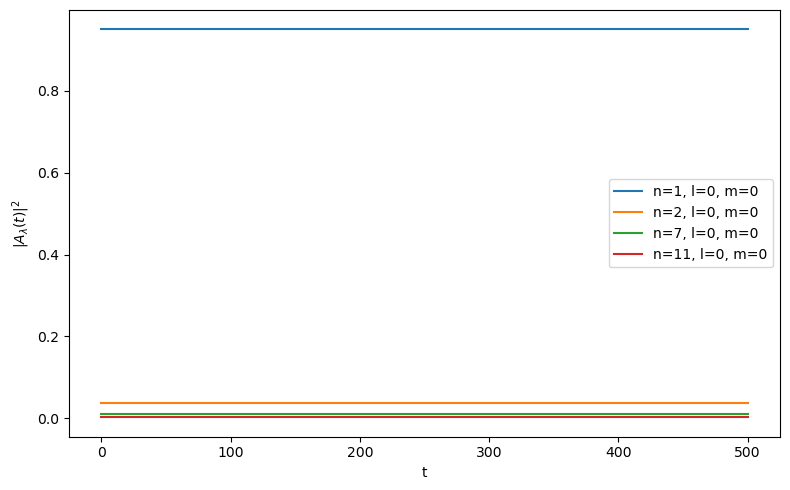

In [46]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.plot(t, powers[:, j], label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda(t)|^2$")
plt.legend()
plt.tight_layout()
plt.show()

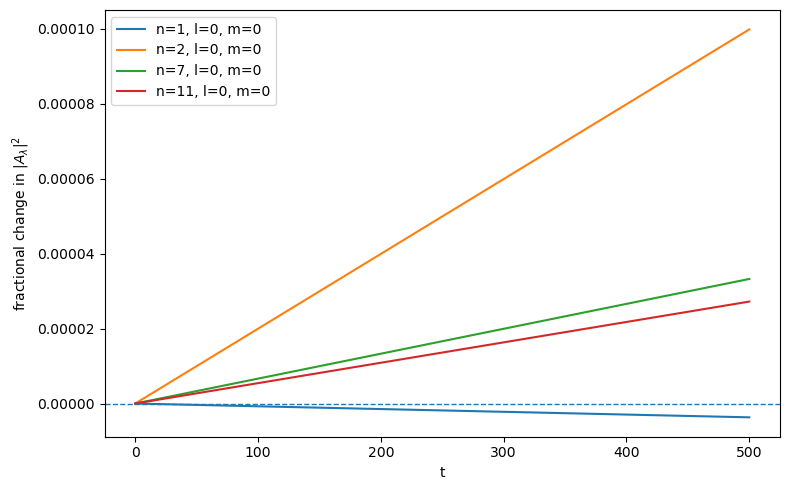

In [47]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    p0 = powers[0, j]
    if p0 != 0:
        plt.plot(t, (powers[:, j] - p0) / p0, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"fractional change in $|A_\lambda|^2$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

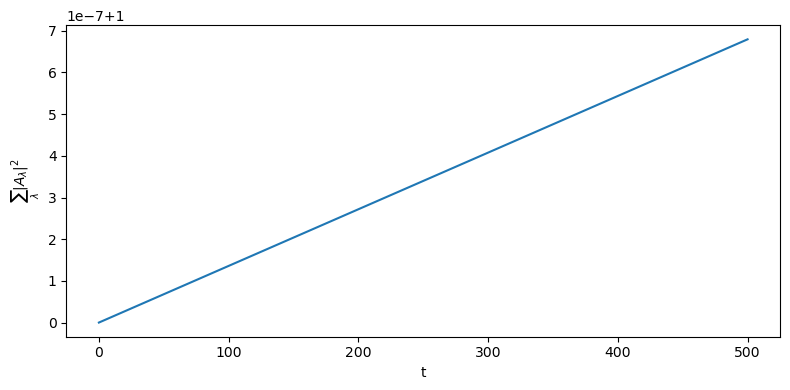

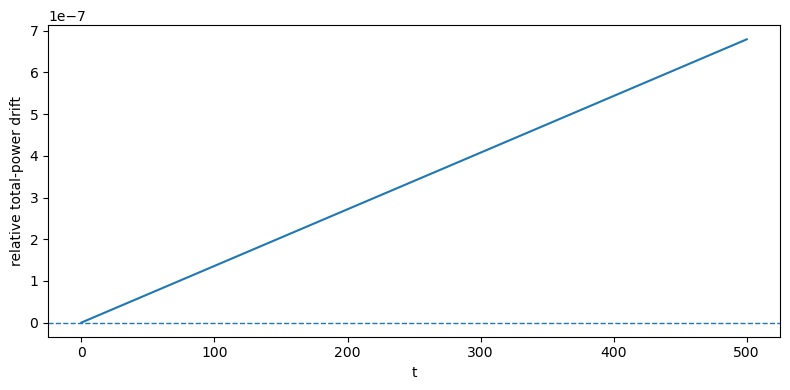

In [48]:
total_power = np.sum(powers, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t, total_power)
plt.xlabel("t")
plt.ylabel(r"$\sum_\lambda |A_\lambda|^2$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, (total_power - total_power[0]) / total_power[0])
plt.xlabel("t")
plt.ylabel("relative total-power drift")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [49]:
def hermitian_adjoint_notes(C):
    """
    Cdag[lam,i,j,k] = conjugate(C[i,lam,k,j])
    """
    return np.conjugate(np.transpose(C, (1, 0, 3, 2)))


def coupling_hermitian_defect(C, mask=None):
    if mask is None:
        mask = np.ones_like(C, dtype=bool)

    Cdag = hermitian_adjoint_notes(C)

    CH = 0.5 * (C + Cdag)
    CA = 0.5 * (C - Cdag)

    norm_H = np.linalg.norm(CH[mask])
    norm_A = np.linalg.norm(CA[mask])

    return norm_A / norm_H, norm_H, norm_A

In [50]:
eta, norm_H, norm_A = coupling_hermitian_defect(C, mask)

print("||C_antiHerm|| / ||C_Herm|| =", eta)
print("||C_Herm|| =", norm_H)
print("||C_antiHerm|| =", norm_A)

||C_antiHerm|| / ||C_Herm|| = 6.258822163334556
||C_Herm|| = 0.006456410115992211
||C_antiHerm|| = 0.04040952272954948


In [51]:
def total_action(A):
    return np.sum(np.abs(A)**2)


def Ndot_notes(t, A, eps, C, Omega, mask=None, phase_mode="real"):
    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask * phase,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    Z = np.vdot(A, F)  # sum_l conjugate(A_l) F_l

    return 2 * eps**2 * np.imag(Z)

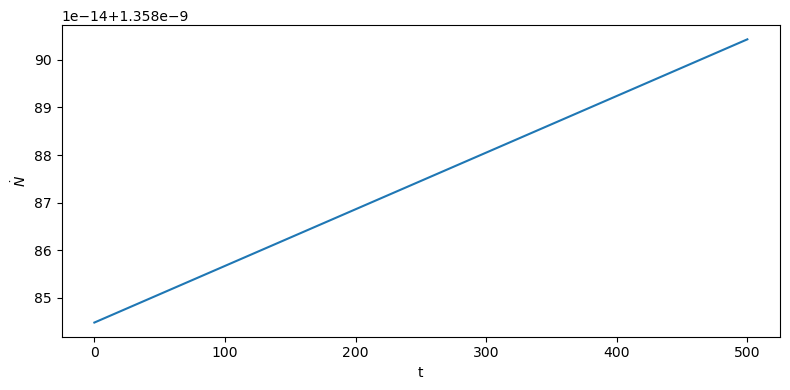

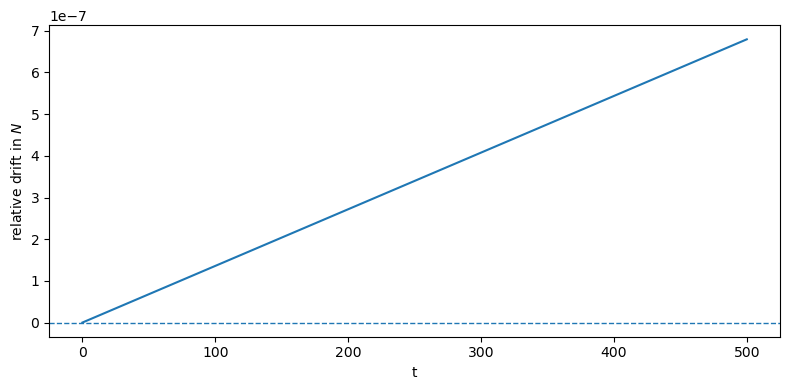

In [52]:
A_of_t = sol.y.T
Ndots = np.array([
    Ndot_notes(ti, Ai, eps, C, Omega, mask, phase_mode="exact")
    for ti, Ai in zip(sol.t, A_of_t)
])

Ntot = np.sum(np.abs(A_of_t)**2, axis=1)

plt.figure(figsize=(8,4))
plt.plot(sol.t, Ndots)
plt.xlabel("t")
plt.ylabel(r"$\dot N$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(sol.t, (Ntot - Ntot[0]) / Ntot[0])
plt.xlabel("t")
plt.ylabel(r"relative drift in $N$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [53]:
Ntot = np.sum(np.abs(sol.y.T)**2, axis=1)
relN = (Ntot - Ntot[0]) / Ntot[0]

slope, intercept = np.polyfit(sol.t, relN, 1)

print("relative drift slope =", slope)
print("relative drift at final time =", relN[-1])

relative drift slope = 1.3588745675566702e-09
relative drift at final time = 6.794372836571584e-07


In [54]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

print("relative anti-Hermitian defect =", np.linalg.norm(C_A[mask]) / np.linalg.norm(C_H[mask]))

relative anti-Hermitian defect = 6.258822163334556


In [55]:
eps_values = [0.025, 0.05, 0.1]
drifts = []

for ep in eps_values:
    sol_ep, omega_tilde_ep, Omega_ep, mask_ep = integrate_A_notes(
        A0,
        T,
        ep,
        omega_arr,
        C,
        nout=1000,
        remove_diag=True,
        include_frequency_shift=True,
        phase_mode="real",
    )

    P_ep = np.abs(sol_ep.y.T)**2
    N_ep = np.sum(P_ep, axis=1)
    drifts.append((N_ep[-1] - N_ep[0]) / N_ep[0])

for ep, drift in zip(eps_values, drifts):
    print(ep, drift, "drift/eps^2 =", drift / ep**2)

0.025 1.061633820742536e-06 drift/eps^2 = 0.0016986141131880572
0.05 4.246970765842129e-06 drift/eps^2 = 0.0016987883063368514
0.1 1.6994849227125467e-05 drift/eps^2 = 0.0016994849227125464


In [56]:
def physical_from_A_solution(sol, omega_arr, eps=1.0, include_eps=False):
    """
    Reconstruct physical/softened amplitudes

        a_lam(t) = eps A_lam(t) exp(-i omega_lam t).

    If include_eps=False, returns A_lam exp(-i omega_lam t),
    matching Mathematica's genInterpsWithSoftener convention up to eps.
    """

    t = sol.t
    A = sol.y.T

    soft = np.exp(-1j * omega_arr[None, :] * t[:, None])

    if include_eps:
        return t, eps * A * soft

    return t, A * soft

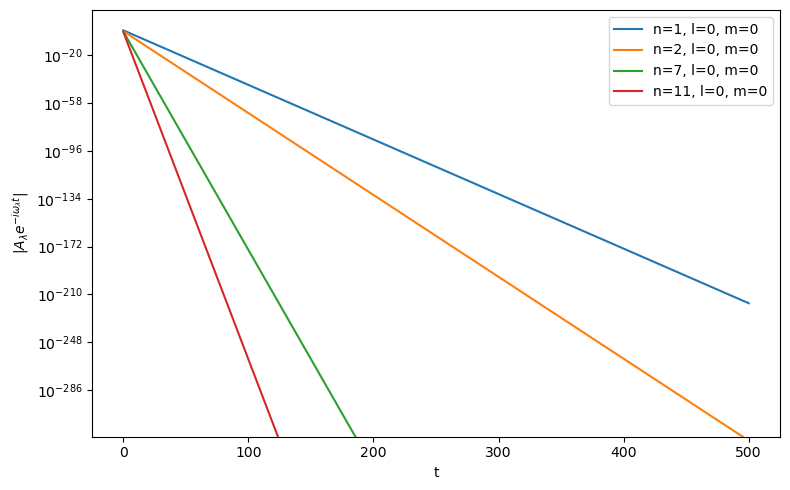

In [57]:
t, a_phys = physical_from_A_solution(sol, omega_arr, eps=eps, include_eps=False)

plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j]), label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|$")
plt.legend()
plt.tight_layout()
plt.show()

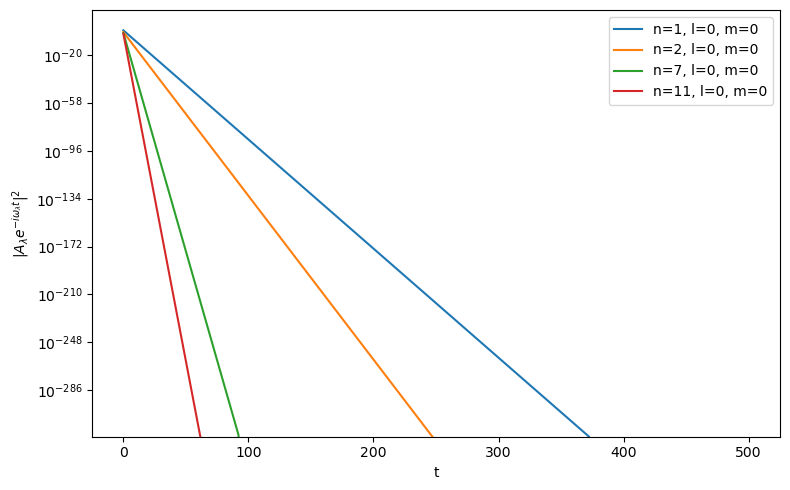

modewise comparison at final time:

n=1, l=0, m=0


NameError: name 'A_num_T' is not defined

In [58]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j])**2, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|^2$")
plt.legend()
plt.tight_layout()
plt.show()
print("modewise comparison at final time:")

for j, k in enumerate(modes):
    print()
    print(mode_label(k))
    print("  numerical:", A_num_T[j])
    print("  pert:     ", A_pert_T[j])
    print("  diff:     ", A_num_T[j] - A_pert_T[j])
    if abs(A_num_T[j]) > 0:
        print("  rel diff: ", abs(A_num_T[j] - A_pert_T[j]) / abs(A_num_T[j]))

In [59]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

sol_H, omega_tilde_H, Omega_H, mask_H = integrate_A_notes(
    A0,
    T,
    0.05,
    omega_arr,
    C_H,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

P_H = np.abs(sol_H.y.T)**2
N_H = np.sum(P_H, axis=1)

print("Hermitian projected drift =",
      (N_H[-1] - N_H[0]) / N_H[0])

Hermitian projected drift = 1.1102230246251568e-16


In [60]:
shift = omega_shift_notes(A0, C)

print("frequency-shift real part:")
print(np.real(shift))

print("nonlinear damping/growth from imaginary part:")
print(np.imag(shift))

frequency-shift real part:
[-1.44663254e-05 -9.53104092e-06 -3.07640712e-06 -4.19189886e-04]
nonlinear damping/growth from imaginary part:
[-0.00089047 -0.00058668 -0.00022442 -0.00618713]


In [61]:
Tlong = 5000.0
eps_sec = 0.05

sol_sec, omega_tilde_sec, Omega_sec, mask_sec = integrate_A_notes(
    A0,
    Tlong,
    eps_sec,
    omega_arr,
    C_H,
    nout=20000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

A_sec = sol_sec.y.T
t_sec = sol_sec.t

In [62]:
P_sec = np.abs(A_sec)**2
N_sec = np.sum(P_sec, axis=1)

print("relative N drift =", (N_sec[-1] - N_sec[0]) / N_sec[0])

relative N drift = -1.1102230246251568e-16


In [63]:
Tlong = 5000.0
eps_sec = 0.05

sol_sec, omega_tilde_sec, Omega_sec, mask_sec = integrate_A_notes(
    A0,
    Tlong,
    eps_sec,
    omega_arr,
    C_H,
    nout=20000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

A_sec = sol_sec.y.T
t_sec = sol_sec.t

In [64]:
P_sec = np.abs(A_sec)**2
N_sec = np.sum(P_sec, axis=1)

print("relative N drift =", (N_sec[-1] - N_sec[0]) / N_sec[0])

relative N drift = -1.1102230246251568e-16


In [65]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi


def normalized_powers_from_A(A):
    P = np.abs(A)**2
    N = np.sum(P, axis=1)
    return P / N[:, None]


def phase_combo(A, inds=(0, 1, 2, 3)):
    """
    Resonant phase combination

        phi = theta_i + theta_j - theta_k - theta_l.

    For four modes, a useful default is theta0 + theta1 - theta2 - theta3.
    """
    i, j, k, l = inds
    th = np.angle(A)
    return wrap_angle(th[:, i] + th[:, j] - th[:, k] - th[:, l])

In [66]:
def poincare_crossings(t, A, phase_inds=(0, 1, 2, 3), direction="positive"):
    p = normalized_powers_from_A(A)
    phi = phase_combo(A, inds=phase_inds)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        phi0 = phi[n - 1]
        phi1 = phi[n]

        if direction == "positive":
            crossed = (phi0 < 0) and (phi1 >= 0)
        elif direction == "negative":
            crossed = (phi0 > 0) and (phi1 <= 0)
        elif direction == "either":
            crossed = phi0 * phi1 <= 0 and abs(phi1 - phi0) > 1e-14
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            denom = phi1 - phi0
            if abs(denom) < 1e-14:
                continue

            frac = -phi0 / denom

            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
    )

phi min = -0.10251512594111478
phi max = -0.10000000000000009
phi initial = -0.10000000000000009
phi final = -0.10251512594111478


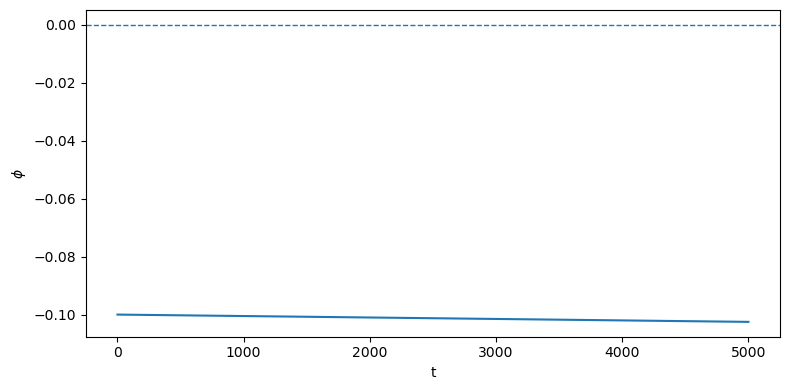

In [67]:
phi = phase_combo(A_sec, inds=(0, 1, 2, 3))

print("phi min =", np.min(phi))
print("phi max =", np.max(phi))
print("phi initial =", phi[0])
print("phi final =", phi[-1])

plt.figure(figsize=(8,4))
plt.plot(t_sec, phi)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel(r"$\phi$")
plt.tight_layout()
plt.show()

In [68]:
def poincare_crossings_level(t, A, phase_inds=(0, 1, 2, 3), level=None, direction="positive"):
    p = normalized_powers_from_A(A)
    phi_raw = phase_combo(A, inds=phase_inds)

    if level is None:
        level = np.mean(phi_raw)

    phi = wrap_angle(phi_raw - level)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        phi0 = phi[n - 1]
        phi1 = phi[n]

        if direction == "positive":
            crossed = (phi0 < 0) and (phi1 >= 0)
        elif direction == "negative":
            crossed = (phi0 > 0) and (phi1 <= 0)
        elif direction == "either":
            crossed = phi0 * phi1 <= 0 and abs(phi1 - phi0) > 1e-14
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            denom = phi1 - phi0
            if abs(denom) < 1e-14:
                continue

            frac = -phi0 / denom
            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
        level,
    )

section level = -0.10125879734609751
number of section points = 1


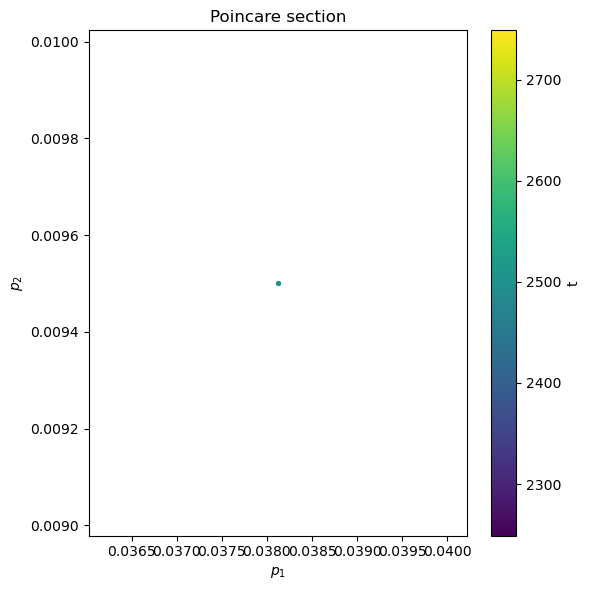

In [69]:
times_sec, pts_sec, inds_sec, level_sec = poincare_crossings_level(
    t_sec,
    A_sec,
    phase_inds=(0, 1, 2, 3),
    level=None,
    direction="either",
)

print("section level =", level_sec)
print("number of section points =", len(times_sec))

if len(times_sec) > 0:
    plt.figure(figsize=(6, 6))
    plt.scatter(pts_sec[:, 1], pts_sec[:, 2], s=8, c=times_sec, cmap="viridis")
    plt.xlabel(r"$p_1$")
    plt.ylabel(r"$p_2$")
    plt.title(r"Poincare section")
    plt.colorbar(label="t")
    plt.tight_layout()
    plt.show()
else:
    print("No crossings. Try a longer integration, different phase_inds, or different section level.")

In [70]:
def power_turning_section(t, A, power_index=1, direction="max"):
    p = normalized_powers_from_A(A)
    y = p[:, power_index]

    dy = np.gradient(y, t)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        dy0 = dy[n - 1]
        dy1 = dy[n]

        if direction == "max":
            crossed = dy0 > 0 and dy1 <= 0
        elif direction == "min":
            crossed = dy0 < 0 and dy1 >= 0
        elif direction == "either":
            crossed = dy0 * dy1 <= 0 and abs(dy1 - dy0) > 1e-14
        else:
            raise ValueError("direction must be 'max', 'min', or 'either'.")

        if crossed:
            denom = dy1 - dy0
            if abs(denom) < 1e-14:
                continue

            frac = -dy0 / denom
            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
    )

In [71]:
times_pow, pts_pow, inds_pow = power_turning_section(
    t_sec,
    A_sec,
    power_index=1,
    direction="max",
)

print("number of power-section points =", len(times_pow))

if len(times_pow) > 0:
    plt.figure(figsize=(6, 6))
    plt.scatter(pts_pow[:, 2], pts_pow[:, 3], s=10, c=times_pow, cmap="viridis")
    plt.xlabel(r"$p_2$")
    plt.ylabel(r"$p_3$")
    plt.title(r"Section at maxima of $p_1$")
    plt.colorbar(label="t")
    plt.tight_layout()
    plt.show()

number of power-section points = 0


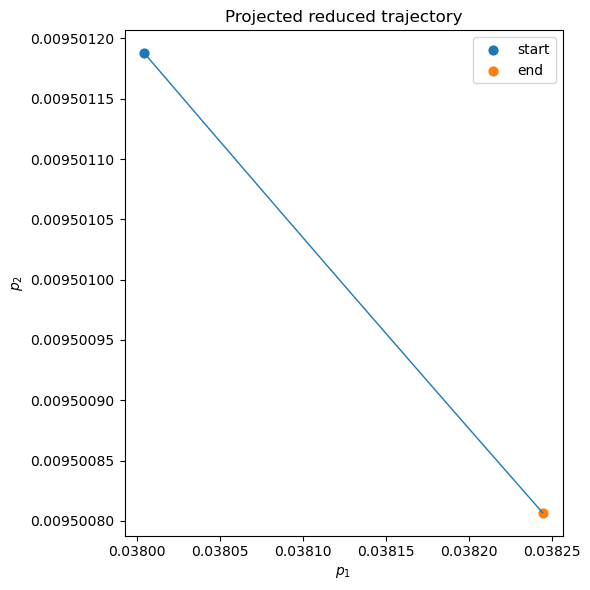

0 p range: 0.9498791216743231 0.9501187648456056 amplitude: 0.0002396431712825553
1 p range: 0.038004750593824244 0.03824446794232604 amplitude: 0.00023971734850179727
2 p range: 0.00950080673677804 0.009501187648456061 amplitude: 3.809116780207483e-07
3 p range: 0.0023752969121140144 0.0023756036465728916 amplitude: 3.0673445887722736e-07


In [72]:
p = normalized_powers_from_A(A_sec)

plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=1)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory")
plt.legend()
plt.tight_layout()
plt.show()

for j in range(p.shape[1]):
    print(j, "p range:", np.min(p[:, j]), np.max(p[:, j]), "amplitude:", np.ptp(p[:, j]))

In [73]:
def rhs_A_slow_resonant(tau, A, C, mask=None):
    """
    Slow-time resonant dynamics:

        i dA_lam/dtau = sum C[lam,i,j,k] A_i A_j bar(A_k).

    This is equivalent to the original system with tau = eps^2 t
    when phases are set to 1.
    """
    if mask is None:
        mask = 1.0

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * F


def integrate_A_slow_resonant(A0, taumax, C, mask=None, nout=20000):
    t_eval = np.linspace(0.0, taumax, nout)

    sol = solve_ivp(
        rhs_A_slow_resonant,
        (0.0, taumax),
        np.asarray(A0, dtype=complex),
        t_eval=t_eval,
        args=(C, mask),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol

In [74]:
def make_A0_from_powers(powers, phases=None):
    powers = np.asarray(powers, dtype=float)
    powers = powers / np.sum(powers)

    if phases is None:
        phases = np.zeros_like(powers)

    return np.sqrt(powers) * np.exp(1j * np.asarray(phases))


A0_balanced = make_A0_from_powers(
    [0.40, 0.30, 0.20, 0.10],
    phases=[0.0, 0.7, 1.8, -0.4],
)

In [75]:
mask_H = build_nondiag_mask_notes(len(modes))

sol_slow = integrate_A_slow_resonant(
    A0_balanced,
    taumax=5000.0,
    C=C_H,
    mask=mask_H,
    nout=30000,
)

A_slow = sol_slow.y.T
tau = sol_slow.t

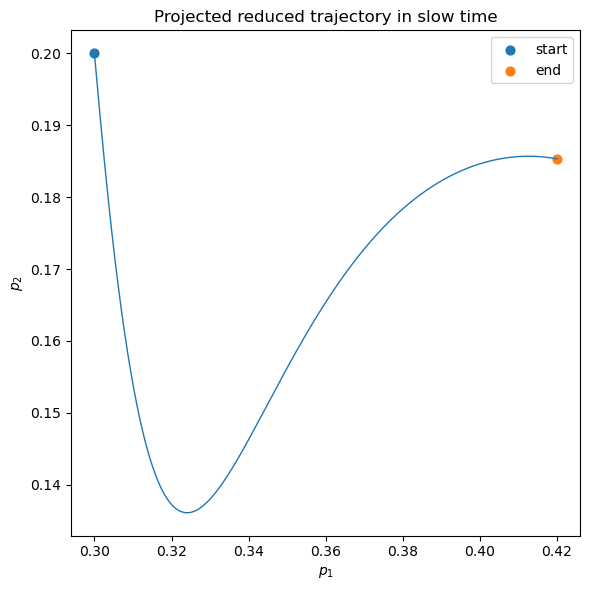

0 p range: 0.33585074948044835 0.3999999999999999 amplitude: 0.06414925051955156
1 p range: 0.30000000000000004 0.41995113619358754 amplitude: 0.1199511361935875
2 p range: 0.1361131316868479 0.19999999999999998 amplitude: 0.06388686831315207
3 p range: 0.05887997434788153 0.1599429677220324 amplitude: 0.10106299337415087


In [76]:
p = normalized_powers_from_A(A_slow)

plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=1)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory in slow time")
plt.legend()
plt.tight_layout()
plt.show()

for j in range(p.shape[1]):
    print(j, "p range:", np.min(p[:, j]), np.max(p[:, j]), "amplitude:", np.ptp(p[:, j]))

In [77]:
from scipy.signal import find_peaks

p = normalized_powers_from_A(A_slow)

q = 1
y = p[:, q]

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)

print("number of p1 maxima =", len(peaks))
print("number of p1 minima =", len(troughs))

print("p1 range:", np.min(y), np.max(y))
print("p2 range:", np.min(p[:, 2]), np.max(p[:, 2]))

if len(peaks) > 1:
    print("estimated p1 period from maxima:")
    print(np.diff(tau[peaks]))

if len(troughs) > 1:
    print("estimated p1 period from minima:")
    print(np.diff(tau[troughs]))

number of p1 maxima = 0
number of p1 minima = 0
p1 range: 0.30000000000000004 0.41995113619358754
p2 range: 0.1361131316868479 0.19999999999999998


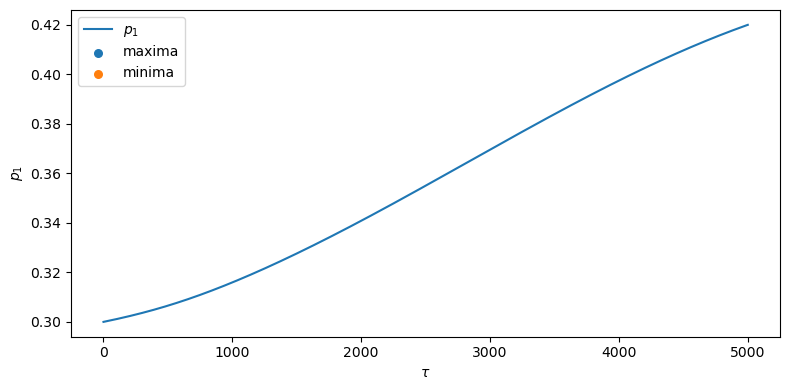

In [78]:
plt.figure(figsize=(8,4))
plt.plot(tau, p[:, 1], label=r"$p_1$")
plt.scatter(tau[peaks], p[peaks, 1], s=30, label="maxima")
plt.scatter(tau[troughs], p[troughs, 1], s=30, label="minima")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$p_1$")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
sol_slow = integrate_A_slow_resonant(
    A0_balanced,
    taumax=50000.0,
    C=C_H,
    mask=mask_H,
    nout=100000,
)

A_slow = sol_slow.y.T
tau = sol_slow.t
p = normalized_powers_from_A(A_slow)

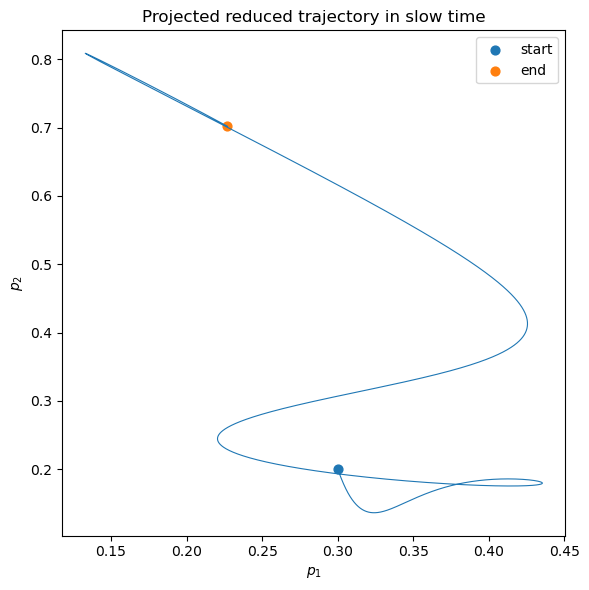

In [80]:
plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=0.8)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory in slow time")
plt.legend()
plt.tight_layout()
plt.show()

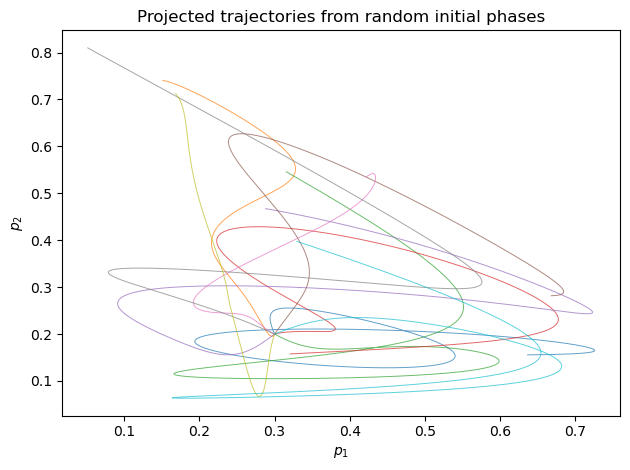

In [81]:
rng = np.random.default_rng(123)

for trial in range(10):
    phases = rng.uniform(0, 2*np.pi, 4)

    A0_trial = make_A0_from_powers(
        [0.40, 0.30, 0.20, 0.10],
        phases=phases,
    )

    sol_trial = integrate_A_slow_resonant(
        A0_trial,
        taumax=30000.0,
        C=C_H,
        mask=mask_H,
        nout=50000,
    )

    A_trial = sol_trial.y.T
    p_trial = normalized_powers_from_A(A_trial)

    plt.plot(p_trial[:, 1], p_trial[:, 2], linewidth=0.7, alpha=0.7)

plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected trajectories from random initial phases")
plt.tight_layout()
plt.show()

In [82]:
def rhs_slow(A, C, mask=None):
    if mask is None:
        mask = 1.0

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * F


def integrate_slow_segment(A0, dtau, C, mask=None, rtol=1e-10, atol=1e-12):
    sol = solve_ivp(
        lambda t, y: rhs_slow(y, C, mask),
        (0.0, dtau),
        np.asarray(A0, dtype=complex),
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )

    return sol.y[:, -1]


def align_global_phase(A, B):
    """
    Remove the global U(1) phase between A and B.
    """
    phase = np.vdot(A, B)
    if abs(phase) == 0:
        return B
    return B * np.exp(-1j * np.angle(phase))


def largest_lyapunov_slow(
    A0,
    C,
    mask=None,
    taumax=5000.0,
    dtau=10.0,
    delta0=1e-8,
    seed=1234,
):
    rng = np.random.default_rng(seed)

    A = np.asarray(A0, dtype=complex).copy()

    dA = rng.normal(size=A.shape) + 1j*rng.normal(size=A.shape)

    # Remove component parallel to global phase direction iA.
    dA -= 1j*A * (np.vdot(1j*A, dA) / np.vdot(1j*A, 1j*A))

    dA *= delta0 / np.linalg.norm(dA)

    B = A + dA

    nsteps = int(taumax / dtau)
    logs = []
    times = []

    accum = 0.0

    for n in range(nsteps):
        A = integrate_slow_segment(A, dtau, C, mask)
        B = integrate_slow_segment(B, dtau, C, mask)

        # quotient global phase
        B = align_global_phase(A, B)

        d = B - A
        dist = np.linalg.norm(d)

        if dist == 0 or not np.isfinite(dist):
            break

        accum += np.log(dist / delta0)

        # renormalize perturbation
        d *= delta0 / dist
        B = A + d

        tau_now = (n + 1) * dtau
        times.append(tau_now)
        logs.append(accum / tau_now)

    return np.array(times), np.array(logs)

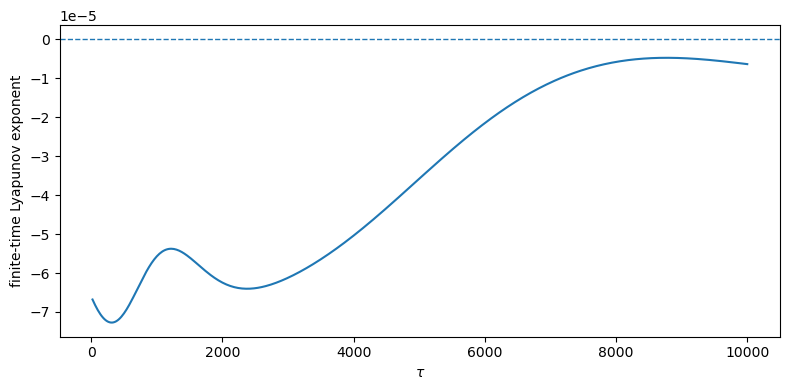

final FTLE = -6.366673931531812e-06


In [83]:
lyap_t, lyap_vals = largest_lyapunov_slow(
    A0_balanced,
    C_H,
    mask=mask_H,
    taumax=10000.0,
    dtau=20.0,
    delta0=1e-8,
)

plt.figure(figsize=(8,4))
plt.plot(lyap_t, lyap_vals)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"finite-time Lyapunov exponent")
plt.tight_layout()
plt.show()

print("final FTLE =", lyap_vals[-1])

In [84]:
def scalar_level_section(t, A, scalar, level=None, direction="either"):
    """
    Poincare section defined by a scalar condition

        scalar(t) = level.

    Typical use:
        p = normalized_powers_from_A(A)
        scalar = p[:, q]

    Returns
    -------
    times : ndarray
        Crossing times.

    pts : ndarray
        Normalized powers at crossings. Shape = (Ncross, Nmode).

    inds : ndarray
        Indices n such that crossing occurs between n-1 and n.

    level : float
        The scalar level used.
    """

    p = normalized_powers_from_A(A)

    y = np.asarray(scalar, dtype=float)

    if level is None:
        level = np.mean(y)

    y = y - level

    pts = []
    times = []
    inds = []

    for n in range(1, len(t)):
        y0 = y[n - 1]
        y1 = y[n]

        if abs(y1 - y0) < 1e-14:
            continue

        if direction == "positive":
            crossed = (y0 < 0) and (y1 >= 0)
        elif direction == "negative":
            crossed = (y0 > 0) and (y1 <= 0)
        elif direction == "either":
            crossed = (y0 * y1 <= 0)
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            frac = -y0 / (y1 - y0)

            if frac < 0 or frac > 1:
                continue

            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            inds.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(inds),
        level,
    )

In [85]:
p = normalized_powers_from_A(A_slow)

q = 0
times_sec, pts_sec,inds_sec, level_sec =  scalar_level_section(
    tau,
    A_slow,
    scalar=p[:, q],
    level=np.mean(p[:, q]),
    direction="positive",
)

print("section points =", len(times_sec))

coords = [r for r in range(p.shape[1]) if r != q]

if len(times_sec) > 5:
    plt.figure(figsize=(6,6))
    plt.scatter(
        pts_sec[:, coords[0]],
        pts_sec[:, coords[1]],
        s=10,
        c=times_sec,
        cmap="viridis",
    )
    plt.xlabel(fr"$p_{coords[0]}$")
    plt.ylabel(fr"$p_{coords[1]}$")
    plt.title(fr"Section at $p_{q}=\langle p_{q}\rangle$")
    plt.colorbar(label=r"$\tau$")
    plt.tight_layout()
    plt.show()

section points = 0


In [86]:
if len(pts_sec) > 5:
    r = coords[0]

    plt.figure(figsize=(6,6))
    plt.scatter(pts_sec[:-1, r], pts_sec[1:, r], s=12)
    plt.xlabel(fr"$p_{r}(n)$")
    plt.ylabel(fr"$p_{r}(n+1)$")
    plt.title("Poincare return map")
    plt.tight_layout()
    plt.show()

In [87]:
P = np.abs(A_slow)**2
N = np.sum(P, axis=1)

print("relative N drift =", (N[-1] - N[0]) / N[0])

relative N drift = 2.4260593534108917e-12


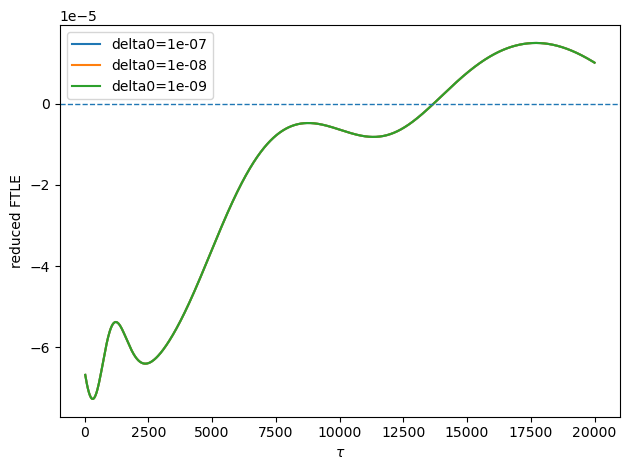

In [88]:
def normalize_to_same_N(B, A):
    NA = np.sum(np.abs(A)**2)
    NB = np.sum(np.abs(B)**2)
    if NB == 0:
        return B
    return B * np.sqrt(NA / NB)

def project_perturbation_reduced(A, dA):
    """
    Project perturbation away from:
      1. norm-changing radial direction A,
      2. global phase direction i A.
    """
    A = np.asarray(A, dtype=complex)
    dA = np.asarray(dA, dtype=complex)

    # Remove norm-changing direction: require Re <A,dA> = 0
    AA = np.vdot(A, A).real
    if AA > 0:
        dA = dA - A * (np.vdot(A, dA).real / AA)

    # Remove global phase direction i A
    g = 1j * A
    gg = np.vdot(g, g).real
    if gg > 0:
        dA = dA - g * (np.vdot(g, dA).real / gg)

    return dA


def largest_lyapunov_slow_reduced(
    A0,
    C,
    mask=None,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
    seed=1234,
):
    rng = np.random.default_rng(seed)

    A = np.asarray(A0, dtype=complex).copy()

    dA = rng.normal(size=A.shape) + 1j*rng.normal(size=A.shape)
    dA = project_perturbation_reduced(A, dA)
    dA *= delta0 / np.linalg.norm(dA)

    B = normalize_to_same_N(A + dA, A)

    nsteps = int(taumax / dtau)
    times = []
    vals = []
    accum = 0.0

    for n in range(nsteps):
        A = integrate_slow_segment(A, dtau, C, mask)
        B = integrate_slow_segment(B, dtau, C, mask)

        # Same norm and quotient global phase
        B = normalize_to_same_N(B, A)
        B = align_global_phase(A, B)

        d = B - A
        d = project_perturbation_reduced(A, d)

        dist = np.linalg.norm(d)

        if dist == 0 or not np.isfinite(dist):
            break

        accum += np.log(dist / delta0)

        d *= delta0 / dist
        B = normalize_to_same_N(A + d, A)

        tau_now = (n + 1) * dtau
        times.append(tau_now)
        vals.append(accum / tau_now)

    return np.array(times), np.array(vals)

for delta0 in [1e-7, 1e-8, 1e-9]:
    lt, lv = largest_lyapunov_slow_reduced(
        A0_balanced,
        C_H,
        mask=mask_H,
        taumax=20000.0,
        dtau=20.0,
        delta0=delta0,
    )

    plt.plot(lt, lv, label=f"delta0={delta0}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel("reduced FTLE")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
A0_regular = make_A0_from_powers(
    [0.85, 0.10, 0.04, 0.01],
    phases=[0.0, 0.7, 1.8, -0.4],
)

lt_reg, lv_reg = largest_lyapunov_slow_reduced(
    A0_regular,
    C_H,
    mask=mask_H,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
)

lt_bal, lv_bal = largest_lyapunov_slow_reduced(
    A0_balanced,
    C_H,
    mask=mask_H,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
)

plt.figure(figsize=(8,4))
plt.plot(lt_reg, lv_reg, label="single-mode dominated")
plt.plot(lt_bal, lv_bal, label="balanced")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel("reduced FTLE")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
sol_check = integrate_A_slow_resonant(
    A0_balanced,
    taumax=20000.0,
    C=C_H,
    mask=mask_H,
    nout=20000,
)

A_check = sol_check.y.T
N_check = np.sum(np.abs(A_check)**2, axis=1)

print("relative N drift =", (N_check[-1] - N_check[0]) / N_check[0])